# Analyse Statistique — Phase 3 : Algorithme Génétique

> **Objectif**
> Transformer les résultats bruts du CSV en insights visuels et statistiques exploitables.
> Ce notebook est conçu pour être **réutilisé en Phase 5** : il suffit de charger les CSV des autres méthodes pour comparer.

---

## Table des matières

1. [Chargement & Statistiques descriptives](#1)
2. [Boxplots — Dispersion par taille](#2)
3. [Histogrammes — Distribution des coûts et des temps](#3)
4. [Évolution — Scalabilité en fonction de n](#4)
5. [Corrélations — Relations entre variables](#5)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os, sys, time, copy

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

TAILLES   = [10, 20, 50]
N_RUNS    = 30
CSV_PATH  = os.path.join('resultats', 'resultats_genetique.csv')
FIG_DIR   = os.path.join('resultats', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

print(f"Configuration : {N_RUNS} runs × tailles {TAILLES}")
print(f"Figures → {FIG_DIR}")


Configuration : 30 runs × tailles [10, 20, 50]
Figures → resultats\figures


---
<a id='1'></a>
## 1. Chargement & Statistiques descriptives

On charge le CSV produit par `grands_tests/grands_tests_genetique.py`.
Si le fichier n'existe pas encore, on lance les tests directement ici.


In [2]:
# ── Chargement ou génération des données ──────────────────────────
if os.path.exists(CSV_PATH):
    df_brut = pd.read_csv(CSV_PATH)
    print(f"✅ CSV chargé : {len(df_brut)} lignes")
else:
    print("⚠️  CSV introuvable — lancement des tests en direct...")
    print("   (Cela peut prendre plusieurs minutes)")

    PHASE4  = os.path.join('..', 'Phase 4')
    RECUIT  = os.path.join('..', 'Algo_Recuit')
    GA_PATH = os.path.abspath('.')
    for p in [PHASE4, RECUIT, GA_PATH]:
        sys.path.insert(0, p)

    from preprocess import generate_instance
    from genetic_algorithm import algorithme_genetique

    lignes = []
    for n in TAILLES:
        print(f"\n  n = {n} clients...")
        for run in range(N_RUNS):
            try:
                instance = generate_instance(n_clients=n, n_vehicles=max(3, n//8), seed=run*100+n)
                t0 = time.time()
                sol, cout, hist = algorithme_genetique(
                    instance, taille_pop=30, n_generations=100, taux_mutation=0.3, seed=run)
                duree = time.time() - t0
                nb_v  = len([r for r in sol if r])
                lignes.append({'n_clients': n, 'run': run+1,
                               'cout': round(cout,2),
                               'temps_s': round(duree,4),
                               'n_vehicules': nb_v})
                print(f"\r    Run {run+1:2d}/{N_RUNS}", end='', flush=True)
            except Exception as e:
                print(f"\n    Run {run+1} échoué : {e}")

    df_brut = pd.DataFrame(lignes)
    os.makedirs(os.path.dirname(CSV_PATH), exist_ok=True)
    df_brut.to_csv(CSV_PATH, index=False)
    print(f"\n✅ CSV sauvegardé → {CSV_PATH}")

df_brut.head(10)


✅ CSV chargé : 4 lignes


,n_clients,run,cout,temps_s,n_vehicules,cout_initial,amelioration_pct,c1_respectee,seed_instance,seed_algo
0,10,1,689.6612,0.0690,3,3.197120e+05,99.78,1,10,0
1,10,2,452.5903,0.0693,3,9.361938e+04,99.52,1,110,1
2,20,1,401028.7572,0.1097,3,1.453156e+06,72.40,1,20,0
3,20,2,235666.5898,0.1086,3,7.584470e+05,68.93,1,120,1


In [3]:
# ── Statistiques descriptives ─────────────────────────────────────
rows = []
for n in TAILLES:
    sub = df_brut[df_brut['n_clients'] == n]
    for col, label in [('cout','Coût'), ('temps_s','Temps (s)'), ('n_vehicules','Nb véhicules')]:
        v = sub[col]
        rows.append({
            'n clients' : n,
            'Métrique'  : label,
            'Moyenne'   : round(v.mean(), 3),
            'Écart-type': round(v.std(), 3),
            'Variance'  : round(v.var(), 3),
            'Min'       : round(v.min(), 3),
            'Médiane'   : round(v.median(), 3),
            'Max'       : round(v.max(), 3),
        })

df_stats = pd.DataFrame(rows)
df_stats.to_csv(os.path.join('resultats', 'statistiques_genetique.csv'), index=False)
df_stats


,n clients,Métrique,Moyenne,Écart-type,Variance,Min,Médiane,Max
0,10,Coût,571.126,167.634,2.810131e+04,452.590,571.126,689.661
1,10,Temps (s),0.069,0.000,0.000000e+00,0.069,0.069,0.069
2,10,Nb véhicules,3.000,0.000,0.000000e+00,3.000,3.000,3.000
3,20,Coût,318347.674,116928.710,1.367232e+10,235666.590,318347.673,401028.757
4,20,Temps (s),0.109,0.001,0.000000e+00,0.109,0.109,0.110
5,20,Nb véhicules,3.000,0.000,0.000000e+00,3.000,3.000,3.000
6,50,Coût,NaN,NaN,NaN,NaN,NaN,NaN
7,50,Temps (s),NaN,NaN,NaN,NaN,NaN,NaN
8,50,Nb véhicules,NaN,NaN,NaN,NaN,NaN,NaN


---
<a id='2'></a>
## 2. Boxplots — Dispersion par taille


C:\Users\fayzr\AppData\Local\Temp\ipykernel_26504\422415985.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dl, x='Taille', y='Valeur',
C:\Users\fayzr\AppData\Local\Temp\ipykernel_26504\422415985.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dl, x='Taille', y='Valeur',
C:\Users\fayzr\AppData\Local\Temp\ipykernel_26504\422415985.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dl, x='Taille', y='Valeur',


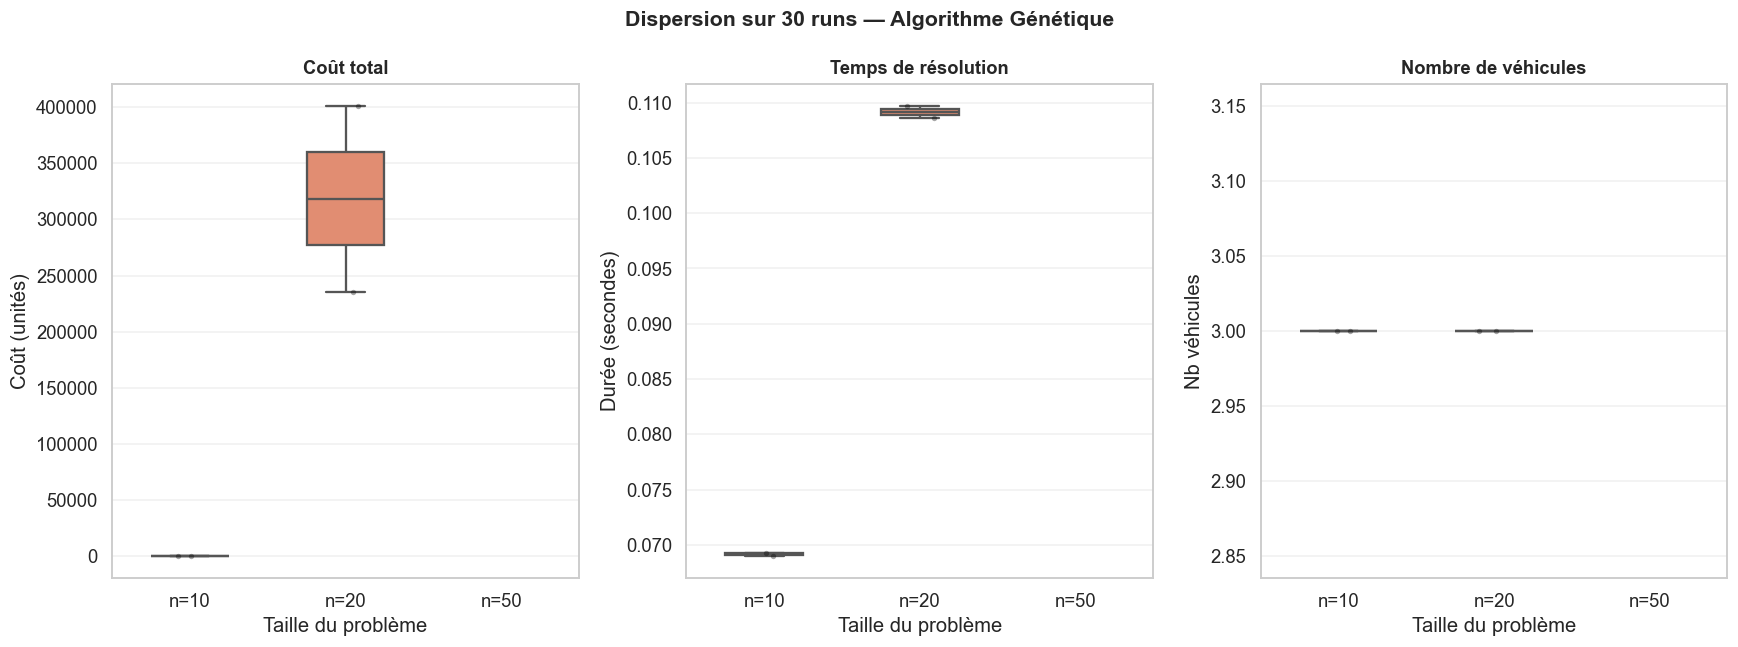

✅ Figure sauvegardée


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
palette = {10: '#4C9BE8', 20: '#F4845F', 50: '#56C596'}

configs = [
    ('cout',       'Coût total',          'Coût (unités)'),
    ('temps_s',    'Temps de résolution', 'Durée (secondes)'),
    ('n_vehicules','Nombre de véhicules', 'Nb véhicules'),
]

for ax, (col, titre, ylabel) in zip(axes, configs):
    data_long = []
    for n in TAILLES:
        for v in df_brut[df_brut['n_clients']==n][col]:
            data_long.append({'Taille': f'n={n}', 'Valeur': v})
    dl = pd.DataFrame(data_long)

    sns.boxplot(data=dl, x='Taille', y='Valeur',
                palette=[palette[n] for n in TAILLES],
                order=[f'n={n}' for n in TAILLES],
                width=0.5, linewidth=1.5, ax=ax)
    sns.stripplot(data=dl, x='Taille', y='Valeur',
                  color='black', alpha=0.35, size=3.5,
                  jitter=True, ax=ax,
                  order=[f'n={n}' for n in TAILLES])

    ax.set_title(titre, fontsize=12, fontweight='bold')
    ax.set_xlabel('Taille du problème')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Dispersion sur 30 runs — Algorithme Génétique',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'boxplots_genetique.png'), bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée")


---
<a id='3'></a>
## 3. Histogrammes — Distribution des coûts et des temps


C:\Users\fayzr\AppData\Local\Temp\ipykernel_26504\1267277035.py:14: RuntimeWarning: Mean of empty slice.
  moy  = vals.mean()
c:\Users\fayzr\anaconda3\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\fayzr\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\fayzr\AppData\Local\Temp\ipykernel_26504\1267277035.py:14: RuntimeWarning: Mean of empty slice.
  moy  = vals.mean()
c:\Users\fayzr\anaconda3\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\fayzr\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\fayzr\AppData\Local\Temp\ipykernel_26504\1267277035.py:14: RuntimeWarning: 

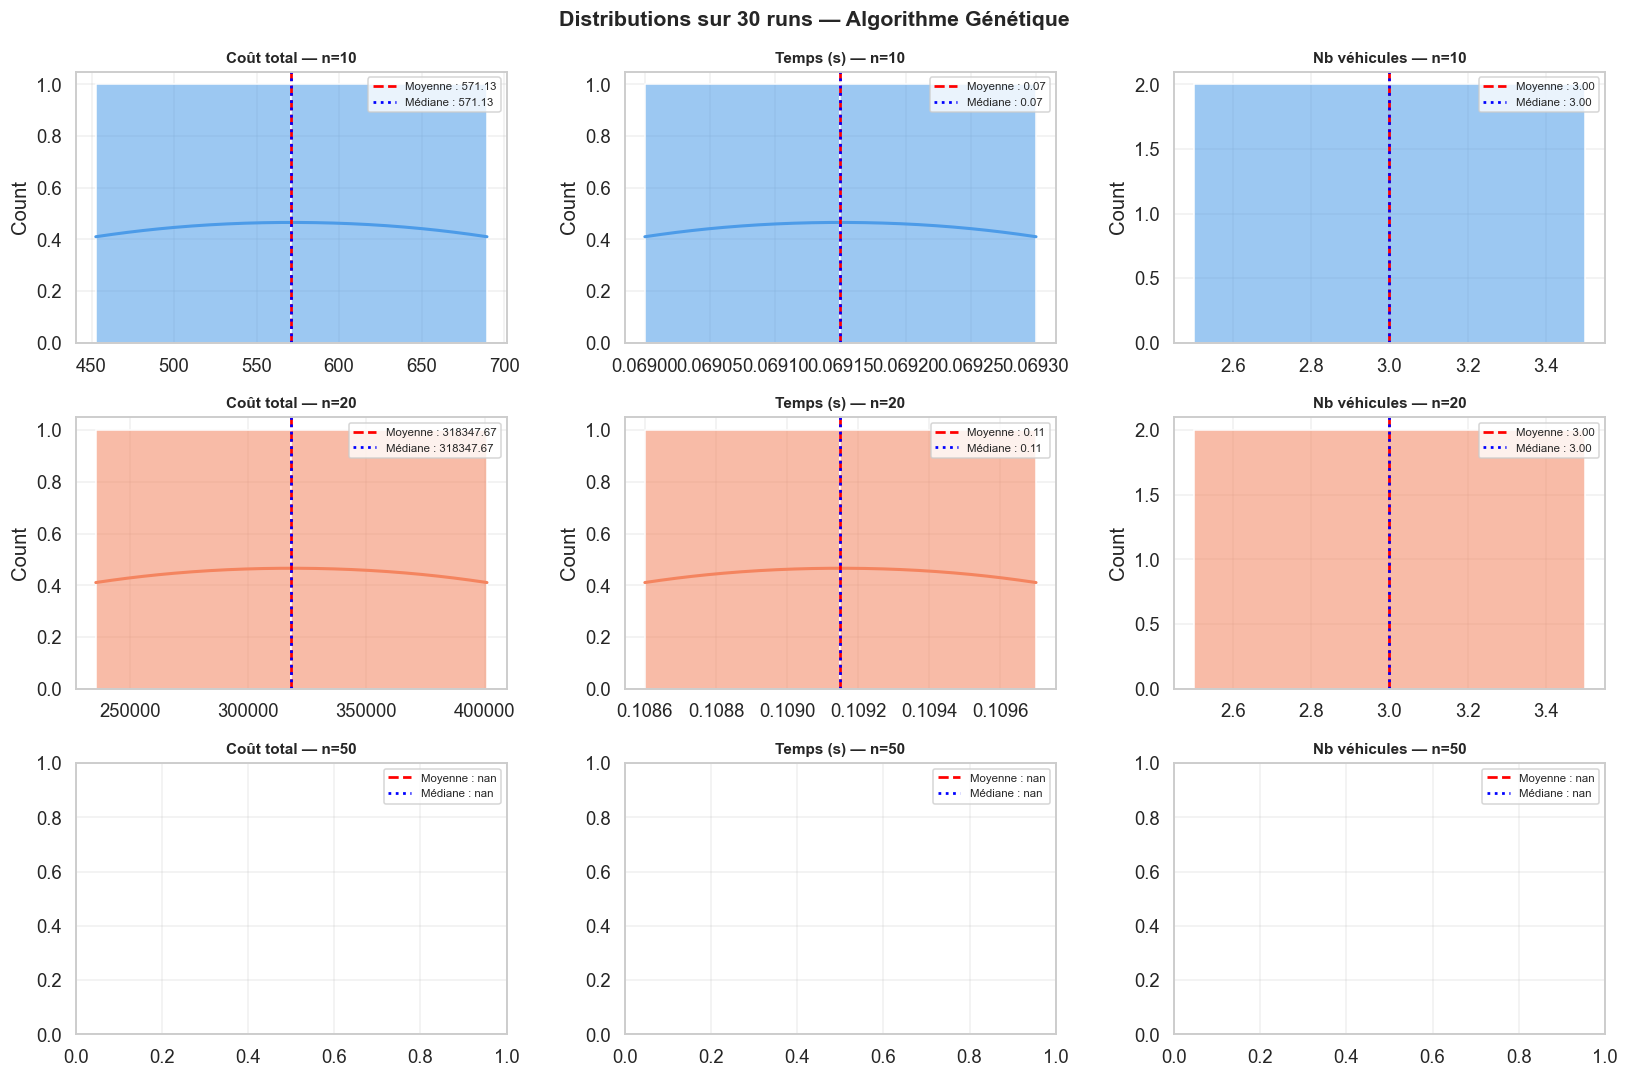

✅ Figure sauvegardée


In [5]:
fig, axes = plt.subplots(len(TAILLES), 3, figsize=(15, 10))
couleurs = {10: '#4C9BE8', 20: '#F4845F', 50: '#56C596'}
cols_info = [
    ('cout',       'Coût total'),
    ('temps_s',    'Temps (s)'),
    ('n_vehicules','Nb véhicules'),
]

for i, n in enumerate(TAILLES):
    sub = df_brut[df_brut['n_clients'] == n]
    for j, (col, titre) in enumerate(cols_info):
        ax   = axes[i][j]
        vals = sub[col].values
        moy  = vals.mean()
        med  = np.median(vals)

        sns.histplot(vals, kde=True, ax=ax,
                     color=couleurs[n], alpha=0.55,
                     line_kws={'linewidth': 2})
        ax.axvline(moy, color='red',  linestyle='--',
                   linewidth=1.8, label=f'Moyenne : {moy:.2f}')
        ax.axvline(med, color='blue', linestyle=':',
                   linewidth=1.8, label=f'Médiane : {med:.2f}')
        ax.legend(fontsize=7.5)
        ax.set_title(f'{titre} — n={n}', fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3)

plt.suptitle('Distributions sur 30 runs — Algorithme Génétique',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'histogrammes_genetique.png'), bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée")


---
<a id='4'></a>
## 4. Évolution — Scalabilité en fonction de n


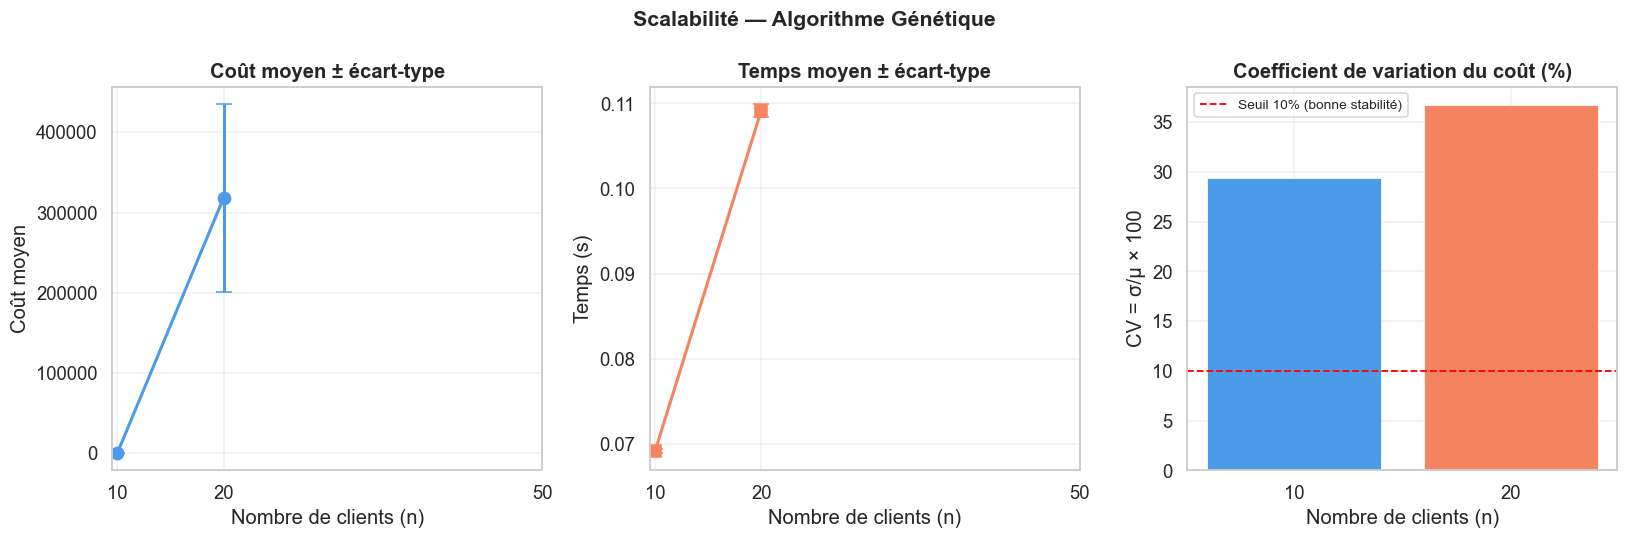

✅ Figure sauvegardée

Interprétation CV :
  n= 10 → CV = 29.4%  ❌ très instable
  n= 20 → CV = 36.7%  ❌ très instable
  n= 50 → CV = nan%  ❌ très instable


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette_n = ['#4C9BE8', '#F4845F', '#56C596']

# Graphique 1 : Coût moyen vs n
moyennes_cout = [df_brut[df_brut['n_clients']==n]['cout'].mean() for n in TAILLES]
errs_cout     = [df_brut[df_brut['n_clients']==n]['cout'].std()  for n in TAILLES]
axes[0].errorbar(TAILLES, moyennes_cout, yerr=errs_cout,
                 fmt='o-', color='#4C9BE8', linewidth=2,
                 capsize=5, markersize=8)
axes[0].set_title('Coût moyen ± écart-type', fontweight='bold')
axes[0].set_xlabel('Nombre de clients (n)')
axes[0].set_ylabel('Coût moyen')
axes[0].set_xticks(TAILLES)

# Graphique 2 : Temps moyen vs n
moyennes_t = [df_brut[df_brut['n_clients']==n]['temps_s'].mean() for n in TAILLES]
errs_t     = [df_brut[df_brut['n_clients']==n]['temps_s'].std()  for n in TAILLES]
axes[1].errorbar(TAILLES, moyennes_t, yerr=errs_t,
                 fmt='s-', color='#F4845F', linewidth=2,
                 capsize=5, markersize=8)
axes[1].set_title('Temps moyen ± écart-type', fontweight='bold')
axes[1].set_xlabel('Nombre de clients (n)')
axes[1].set_ylabel('Temps (s)')
axes[1].set_xticks(TAILLES)

# Graphique 3 : Coefficient de variation (écart-type / moyenne) = stabilité
cv_cout = [df_brut[df_brut['n_clients']==n]['cout'].std() /
           df_brut[df_brut['n_clients']==n]['cout'].mean() * 100
           for n in TAILLES]
axes[2].bar([str(n) for n in TAILLES], cv_cout,
            color=palette_n, edgecolor='white', linewidth=0.5)
axes[2].set_title('Coefficient de variation du coût (%)', fontweight='bold')
axes[2].set_xlabel('Nombre de clients (n)')
axes[2].set_ylabel('CV = σ/μ × 100')
axes[2].axhline(10, color='red', linestyle='--', linewidth=1.2,
                label='Seuil 10% (bonne stabilité)')
axes[2].legend(fontsize=9)

for ax in axes:
    ax.grid(alpha=0.3)

plt.suptitle('Scalabilité — Algorithme Génétique', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'scalabilite_genetique.png'), bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée")
print()
print("Interprétation CV :")
for n, cv in zip(TAILLES, cv_cout):
    stabilite = '✅ stable' if cv < 10 else ('⚠️  instable' if cv < 20 else '❌ très instable')
    print(f"  n={n:3d} → CV = {cv:.1f}%  {stabilite}")


---
<a id='5'></a>
## 5. Corrélations — Relations entre variables


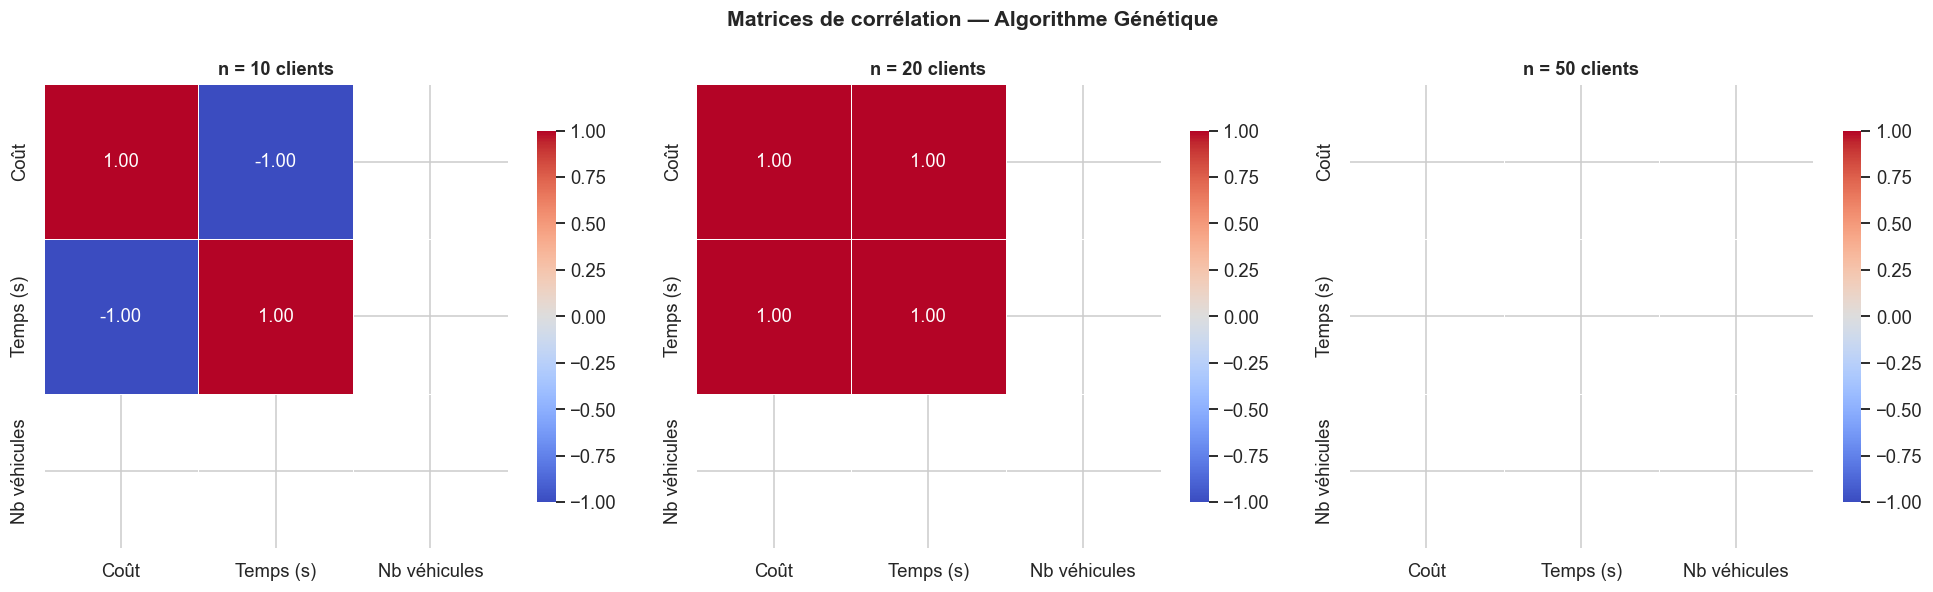

✅ Figure sauvegardée


In [7]:
fig, axes = plt.subplots(1, len(TAILLES), figsize=(6*len(TAILLES), 5))
fig.suptitle('Matrices de corrélation — Algorithme Génétique',
             fontsize=14, fontweight='bold', y=1.02)

for ax, n in zip(axes, TAILLES):
    sub = df_brut[df_brut['n_clients'] == n][['cout','temps_s','n_vehicules']]
    sub = sub.rename(columns={'cout':'Coût','temps_s':'Temps (s)','n_vehicules':'Nb véhicules'})
    corr = sub.corr()

    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True

    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                vmin=-1, vmax=1, ax=ax,
                linewidths=0.5, square=True,
                cbar_kws={'shrink': 0.8},
                annot_kws={'size': 12})
    ax.set_title(f'n = {n} clients', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'correlations_genetique.png'), bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée")


In [8]:
# ── Test de Shapiro-Wilk (normalité) + résumé final ──────────────
print("=" * 58)
print("  TEST DE NORMALITÉ — Shapiro-Wilk (p > 0.05 → normale)")
print("=" * 58)
for n in TAILLES:
    sub  = df_brut[df_brut['n_clients'] == n]['cout']
    stat, pval = stats.shapiro(sub)
    norm = '✅ normale' if pval > 0.05 else '❌ non normale'
    print(f"  n={n:3d} | W={stat:.4f} | p={pval:.4f} | {norm}")

print()
print("=" * 58)
print("  FICHIERS GÉNÉRÉS")
print("=" * 58)
for f in os.listdir(FIG_DIR):
    print(f"  📊 {os.path.join(FIG_DIR, f)}")
print(f"  📄 resultats/statistiques_genetique.csv")
print(f"  📄 resultats/resultats_genetique.csv")


  TEST DE NORMALITÉ — Shapiro-Wilk (p > 0.05 → normale)
  n= 10 | W=nan | p=nan | ❌ non normale
  n= 20 | W=nan | p=nan | ❌ non normale
  n= 50 | W=nan | p=nan | ❌ non normale

  FICHIERS GÉNÉRÉS
  📊 resultats\figures\boxplots_genetique.png
  📊 resultats\figures\correlations_genetique.png
  📊 resultats\figures\histogrammes_genetique.png
  📊 resultats\figures\scalabilite_genetique.png
  📄 resultats/statistiques_genetique.csv
  📄 resultats/resultats_genetique.csv


C:\Users\fayzr\AppData\Local\Temp\ipykernel_26504\3554068991.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, pval = stats.shapiro(sub)
